# Initial EDA

In [2]:
# ---- Imports ----
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("../data/raw/synthetic_coffee_health_10000.csv")
data.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
# ---- Glance at the missing values ----
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [ ]:
# ---- Descriptive Statistics ----
data.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


# First glance at the data

Our dataset is composed of 10,000 instances with 15 variables.

The info is pretty much complete, no Null Values, the only column with missing values is "Healt_Issues" with 5941 NaN values but this mean the individual has no Healt Issues at all.

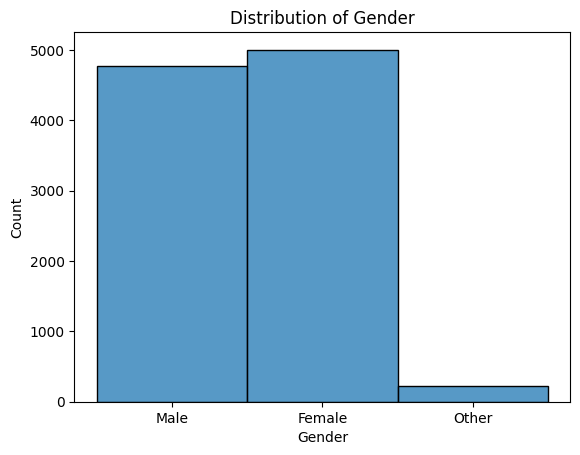

In [36]:
sns.histplot(data['Gender'])
plt.title('Distribution of Gender')
plt.show()

In this dataset we have are:
>- 5001 woman (50.01%)
>- 4773 man (47.73%)
>- 226 other (2.26%)

This is slightly different than the real world but normal, according to the *Ined - Institut National d’Études Démographiques* 

*"Of every 1,000 people, 504 are men (50.4%) and 496 are women (49.6%)" (Are There More Men or More Women in the World?, 2020)*
‌

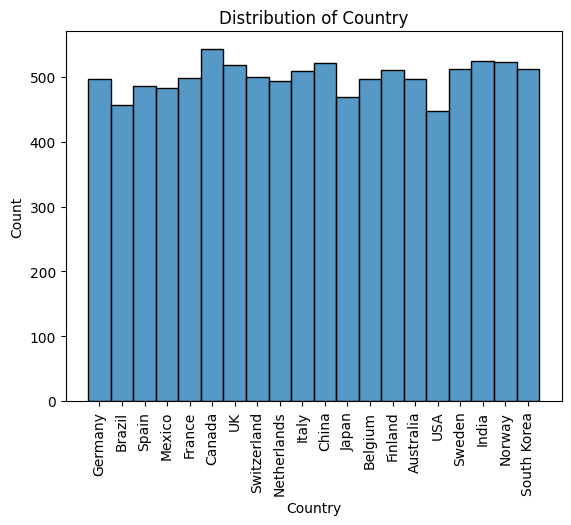

In [31]:
sns.histplot(data['Country'])
plt.title('Distribution of Country')
plt.xticks(rotation=90)
plt.show()

The distribution of individuals per country in our data is pretty uniform.

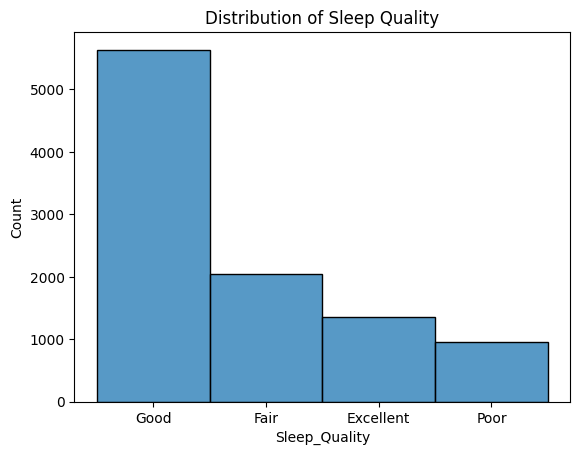

In [73]:
sns.histplot(data['Sleep_Quality'])
plt.title('Distribution of Sleep Quality')
plt.show()

Most of the individuals in the dataset have a Good sleep quality.

>- Excellent sleep quality 13.52%
>- Good sleep quality 56.37%
>- Fair sleep quality 20.50%
>- Poor sleep quality 9.61%

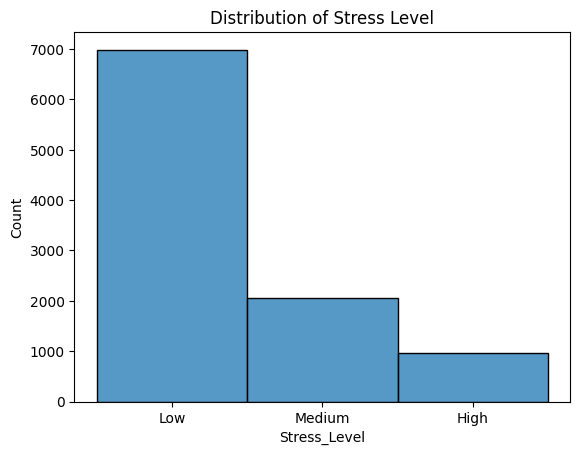

In [37]:
sns.histplot(data['Stress_Level'])
plt.title('Distribution of Stress Level')
plt.show()

Similar than with the sleep quality it appears that the individuals in the dataset have a nice life because most of them present low stress levels.

>- Low stress level 69.89%
>- Medium stress level 20.50%
>- High stress level 9.61%

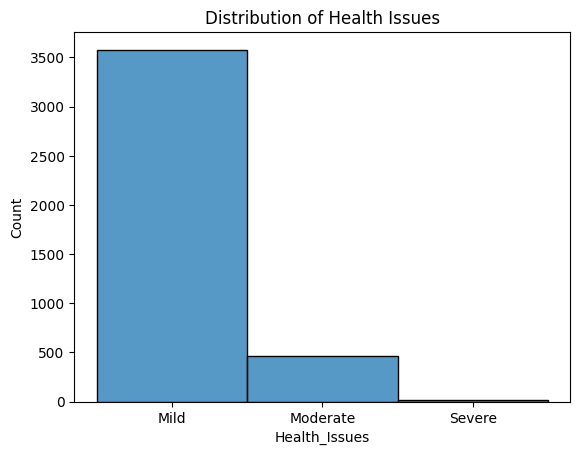

In [38]:
sns.histplot(data['Health_Issues'].dropna())
plt.title('Distribution of Health Issues')
plt.show()

The difference in between the health issues in the population of this dataset is really noticeable, most of them present mild health isues and barely any of them present severe health isues, we could say is a healthy population.

Based on the last proposition we can infer than the missing values on this column may not be missing at all but can be interpreted as no health issues at all.

With the following idea the percentages of health issues would be the next ones.

>- No health issues 59.41%
>- Mild health issues 35.79%
>- Moderate health issues 4.63%
>- Severe health issues 0.17%

In [85]:
females = data[(data['Health_Issues'] == 'Moderate')]
females_count = females['Health_Issues'].count()
females_count

np.int64(463)

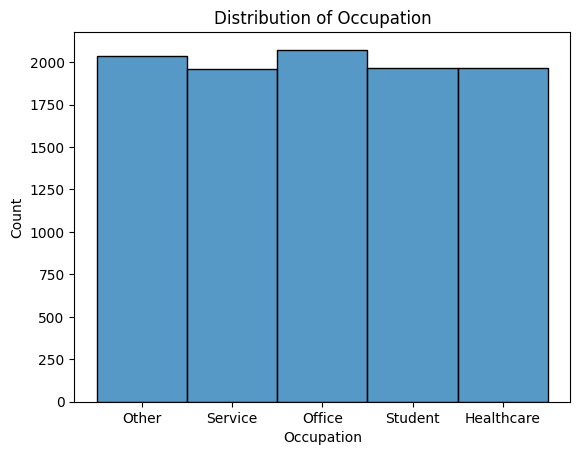

In [39]:
sns.histplot(data['Occupation'])
plt.title('Distribution of Occupation')
plt.show()

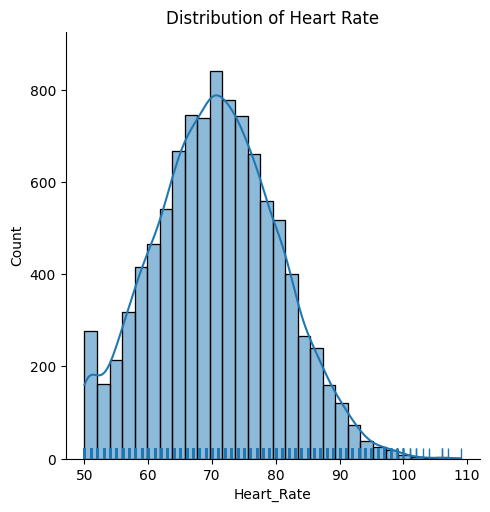

In [22]:
sns.displot(data['Heart_Rate'], bins=30, kde=True, rug=True)
plt.title('Distribution of Heart Rate')
plt.show()

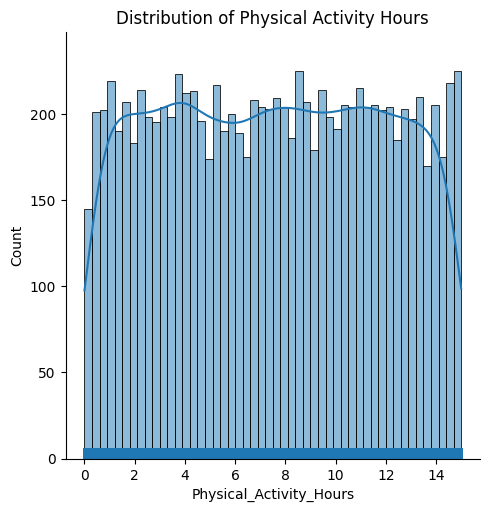

In [24]:
sns.displot(data['Physical_Activity_Hours'], bins=50, kde=True, rug=True)
plt.title('Distribution of Physical Activity Hours')
plt.show()

Smoking
0    7996
1    2004
Name: count, dtype: int64


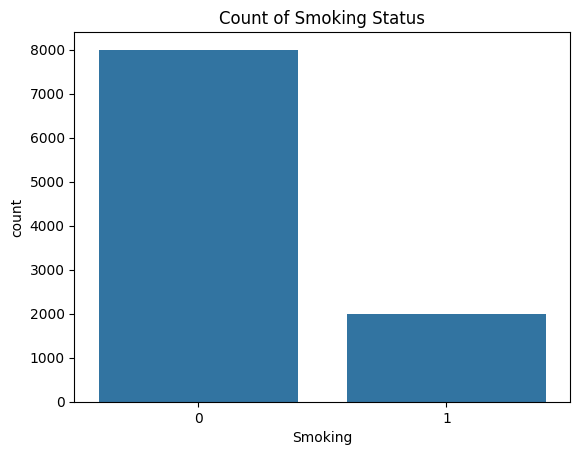

In [ ]:
conteo = data.value_counts(data['Smoking'])
print(conteo)
sns.countplot(x='Smoking', data=data)
plt.title('Count of Smoking Status')
plt.show()

Most of the people in this dataset do not smoke.

Alcohol_Consumption
0    6993
1    3007
Name: count, dtype: int64


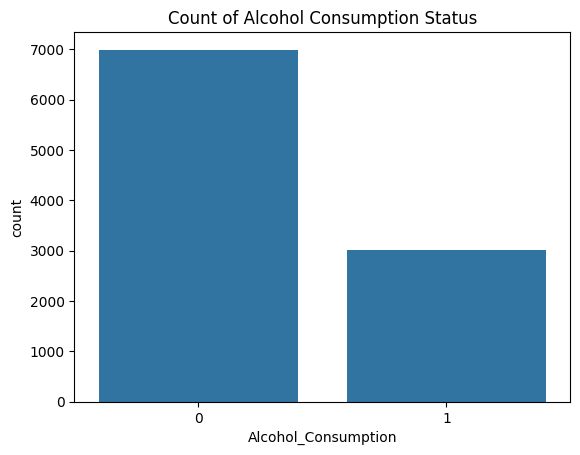

In [ ]:
conteo = data.value_counts(data['Alcohol_Consumption'])
print(conteo)
sns.countplot(x='Alcohol_Consumption', data=data)
plt.title('Count of Alcohol Consumption Status')
plt.show()

Most of the people in this dataset do not consume alcohol, but there are more consumers of alcohol than smokers.

# Checking for Outliers

Text(0.5, 1.0, 'Caffeine Intake by Sleep Quality')

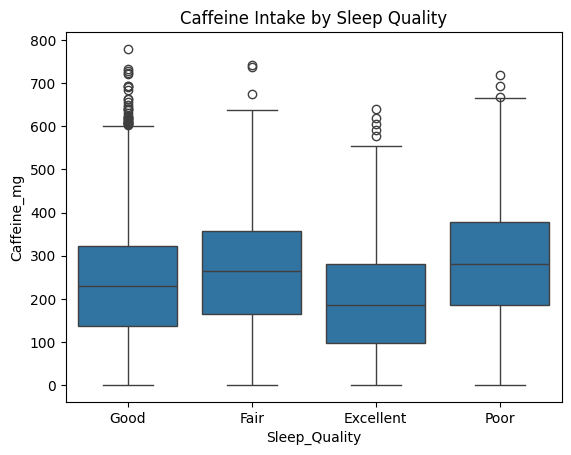

In [14]:
sns.boxplot(x='Sleep_Quality', y='Caffeine_mg', data=data)
plt.title('Caffeine Intake by Sleep Quality')

# Analyzing the Alcohol Consumption

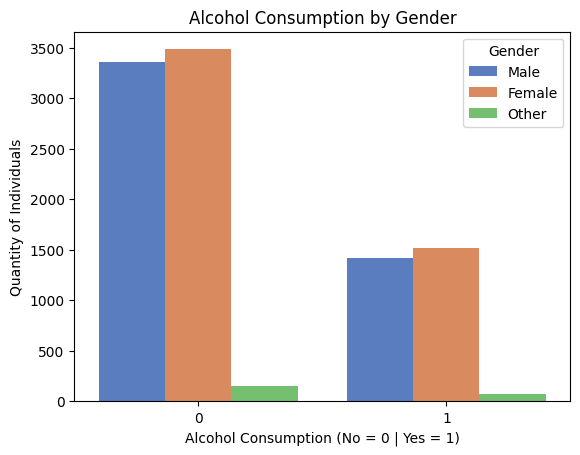

In [42]:
sns.countplot(x='Alcohol_Consumption', hue='Gender', data=data, palette='muted')
plt.title('Alcohol Consumption by Gender')
plt.xlabel('Alcohol Consumption (No = 0 | Yes = 1)')
plt.ylabel('Quantity of Individuals')
plt.show()

We notice that in this dataset most of the individuals do not consume alcohol, and amongst the one who does consume alcohol, there are more women consuming alcohol than men.

Consumption of alcohol is divided the next way:

> - 3485 women do not consume alcohol (34.85%)
> - 3354 men do not consume alcohol (33.54%)
> - 0.72% by Others

> - 1516 women consume alcohol (15.16%)
> - 1419 men consume alcohol (14.19%)
> - 1.54% by others

In general *69.11%*  of the individuals compounding this dataset does not consume alcohol meanwhile the other *29.89%* does.

In [66]:
females_alcohol = data[(data['Gender'] == 'Female') & (data['Alcohol_Consumption'] == 1)]
females_alcohol_count = females_alcohol['Alcohol_Consumption'].count()
females_alcohol_count

np.int64(1516)

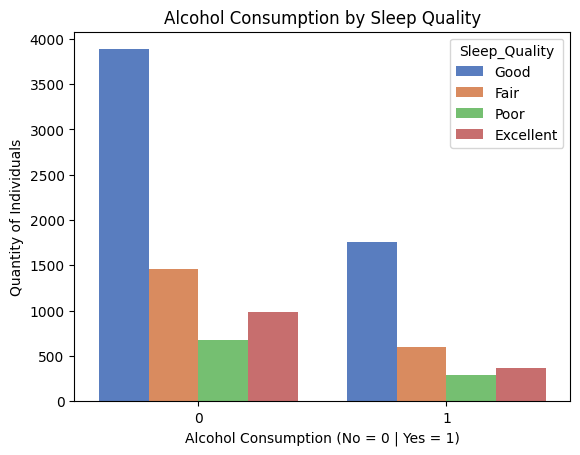

In [49]:
sns.countplot(x='Alcohol_Consumption', hue='Sleep_Quality', data=data, palette='muted')
plt.title('Alcohol Consumption by Sleep Quality')
plt.xlabel('Alcohol Consumption (No = 0 | Yes = 1)')
plt.ylabel('Quantity of Individuals')
plt.show()

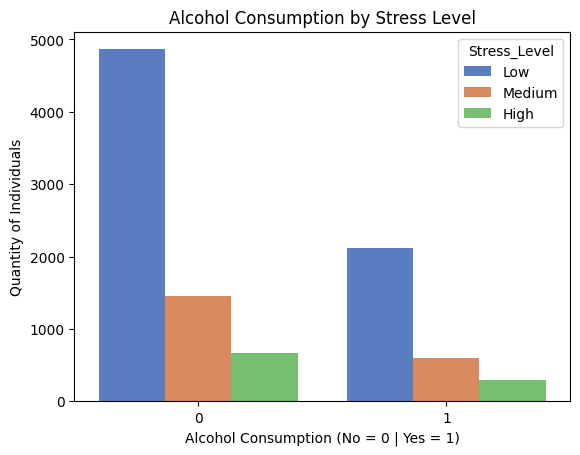

In [51]:
sns.countplot(x='Alcohol_Consumption', hue='Stress_Level', data=data, palette='muted')
plt.title('Alcohol Consumption by Stress Level')
plt.xlabel('Alcohol Consumption (No = 0 | Yes = 1)')
plt.ylabel('Quantity of Individuals')
plt.show()

We notice similar patterns between the ones who consume alcohol and the ones who does not, wich may tell us that the alcohol consumption does not directly affects the stress levels or the sleep quality, but we will continue to analyze our data to conclude about this.

# Analyzing the Smoking Status

Similar as alcohol, cigarrettes can affect our health in many ways, so we will analyze how it affects us.

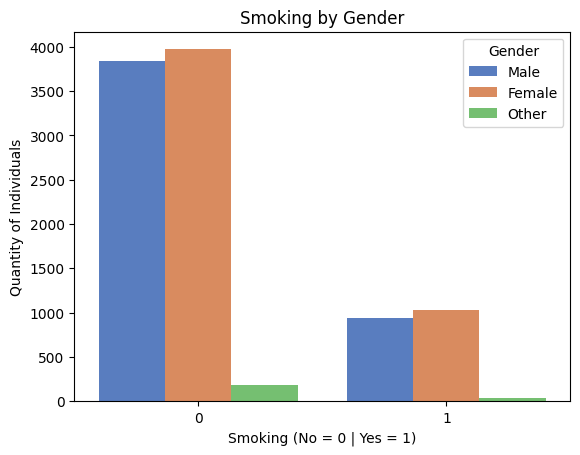

In [56]:
sns.countplot(x='Smoking', hue='Gender', data=data, palette='muted')
plt.title('Smoking by Gender')
plt.xlabel('Smoking (No = 0 | Yes = 1)')
plt.ylabel('Quantity of Individuals')
plt.show()

Similar as

In [67]:
females_smoking = data[(data['Gender'] == 'Female') & (data['Smoking'] == 1)]
females_smoking_count = females_alcohol['Smoking'].count()
females_smoking_count

np.int64(1516)

# Jointplots

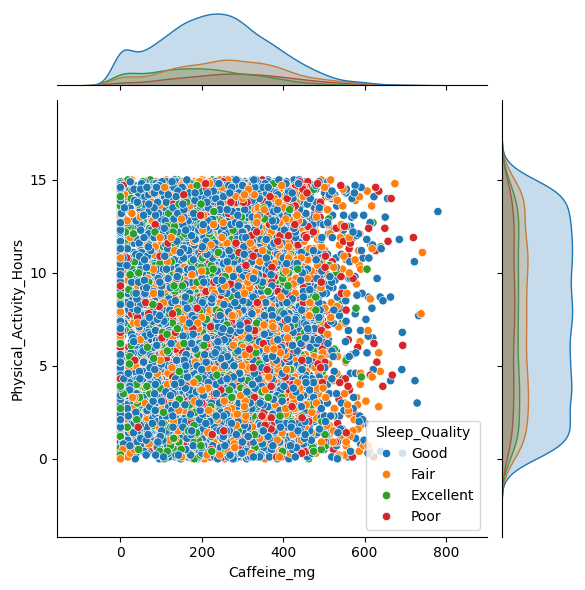

In [66]:
sns.jointplot(data=data, y="Physical_Activity_Hours", x="Caffeine_mg", hue="Sleep_Quality")

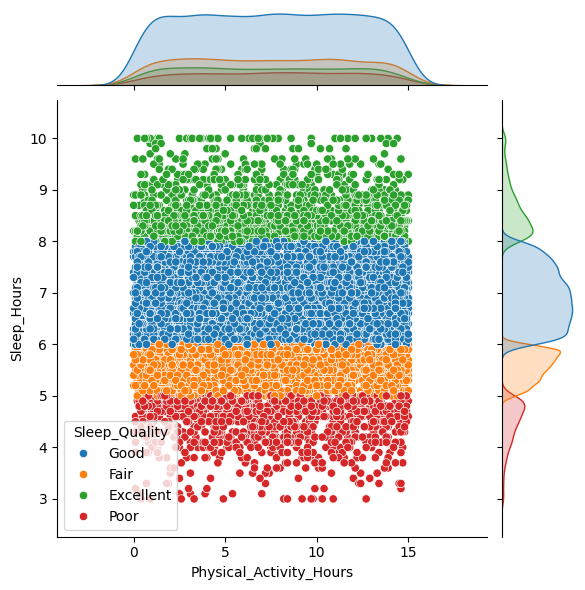

In [6]:
sns.jointplot(data=data, x="Physical_Activity_Hours", y="Sleep_Hours", hue="Sleep_Quality")

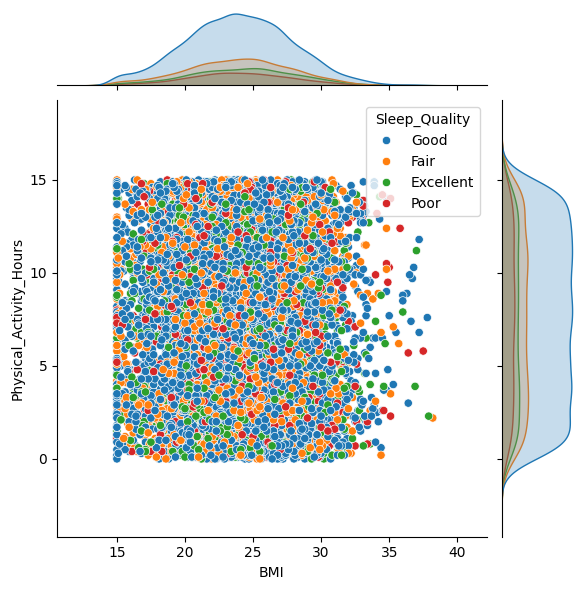

In [8]:
sns.jointplot(data=data, y="Physical_Activity_Hours", x="BMI", hue="Sleep_Quality")

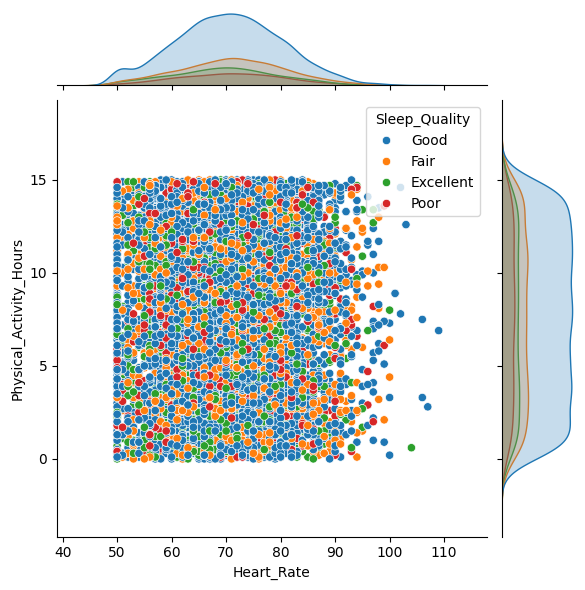

In [11]:
sns.jointplot(data=data, y="Physical_Activity_Hours", x="Heart_Rate", hue="Sleep_Quality")

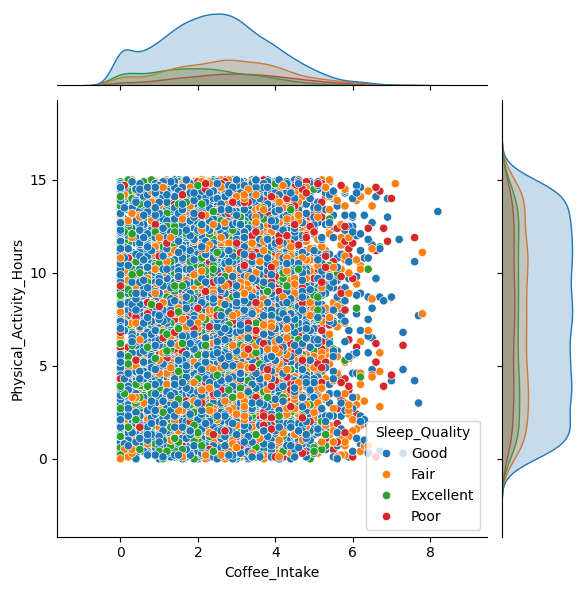

In [10]:
sns.jointplot(data=data, y="Physical_Activity_Hours", x="Coffee_Intake", hue="Sleep_Quality")

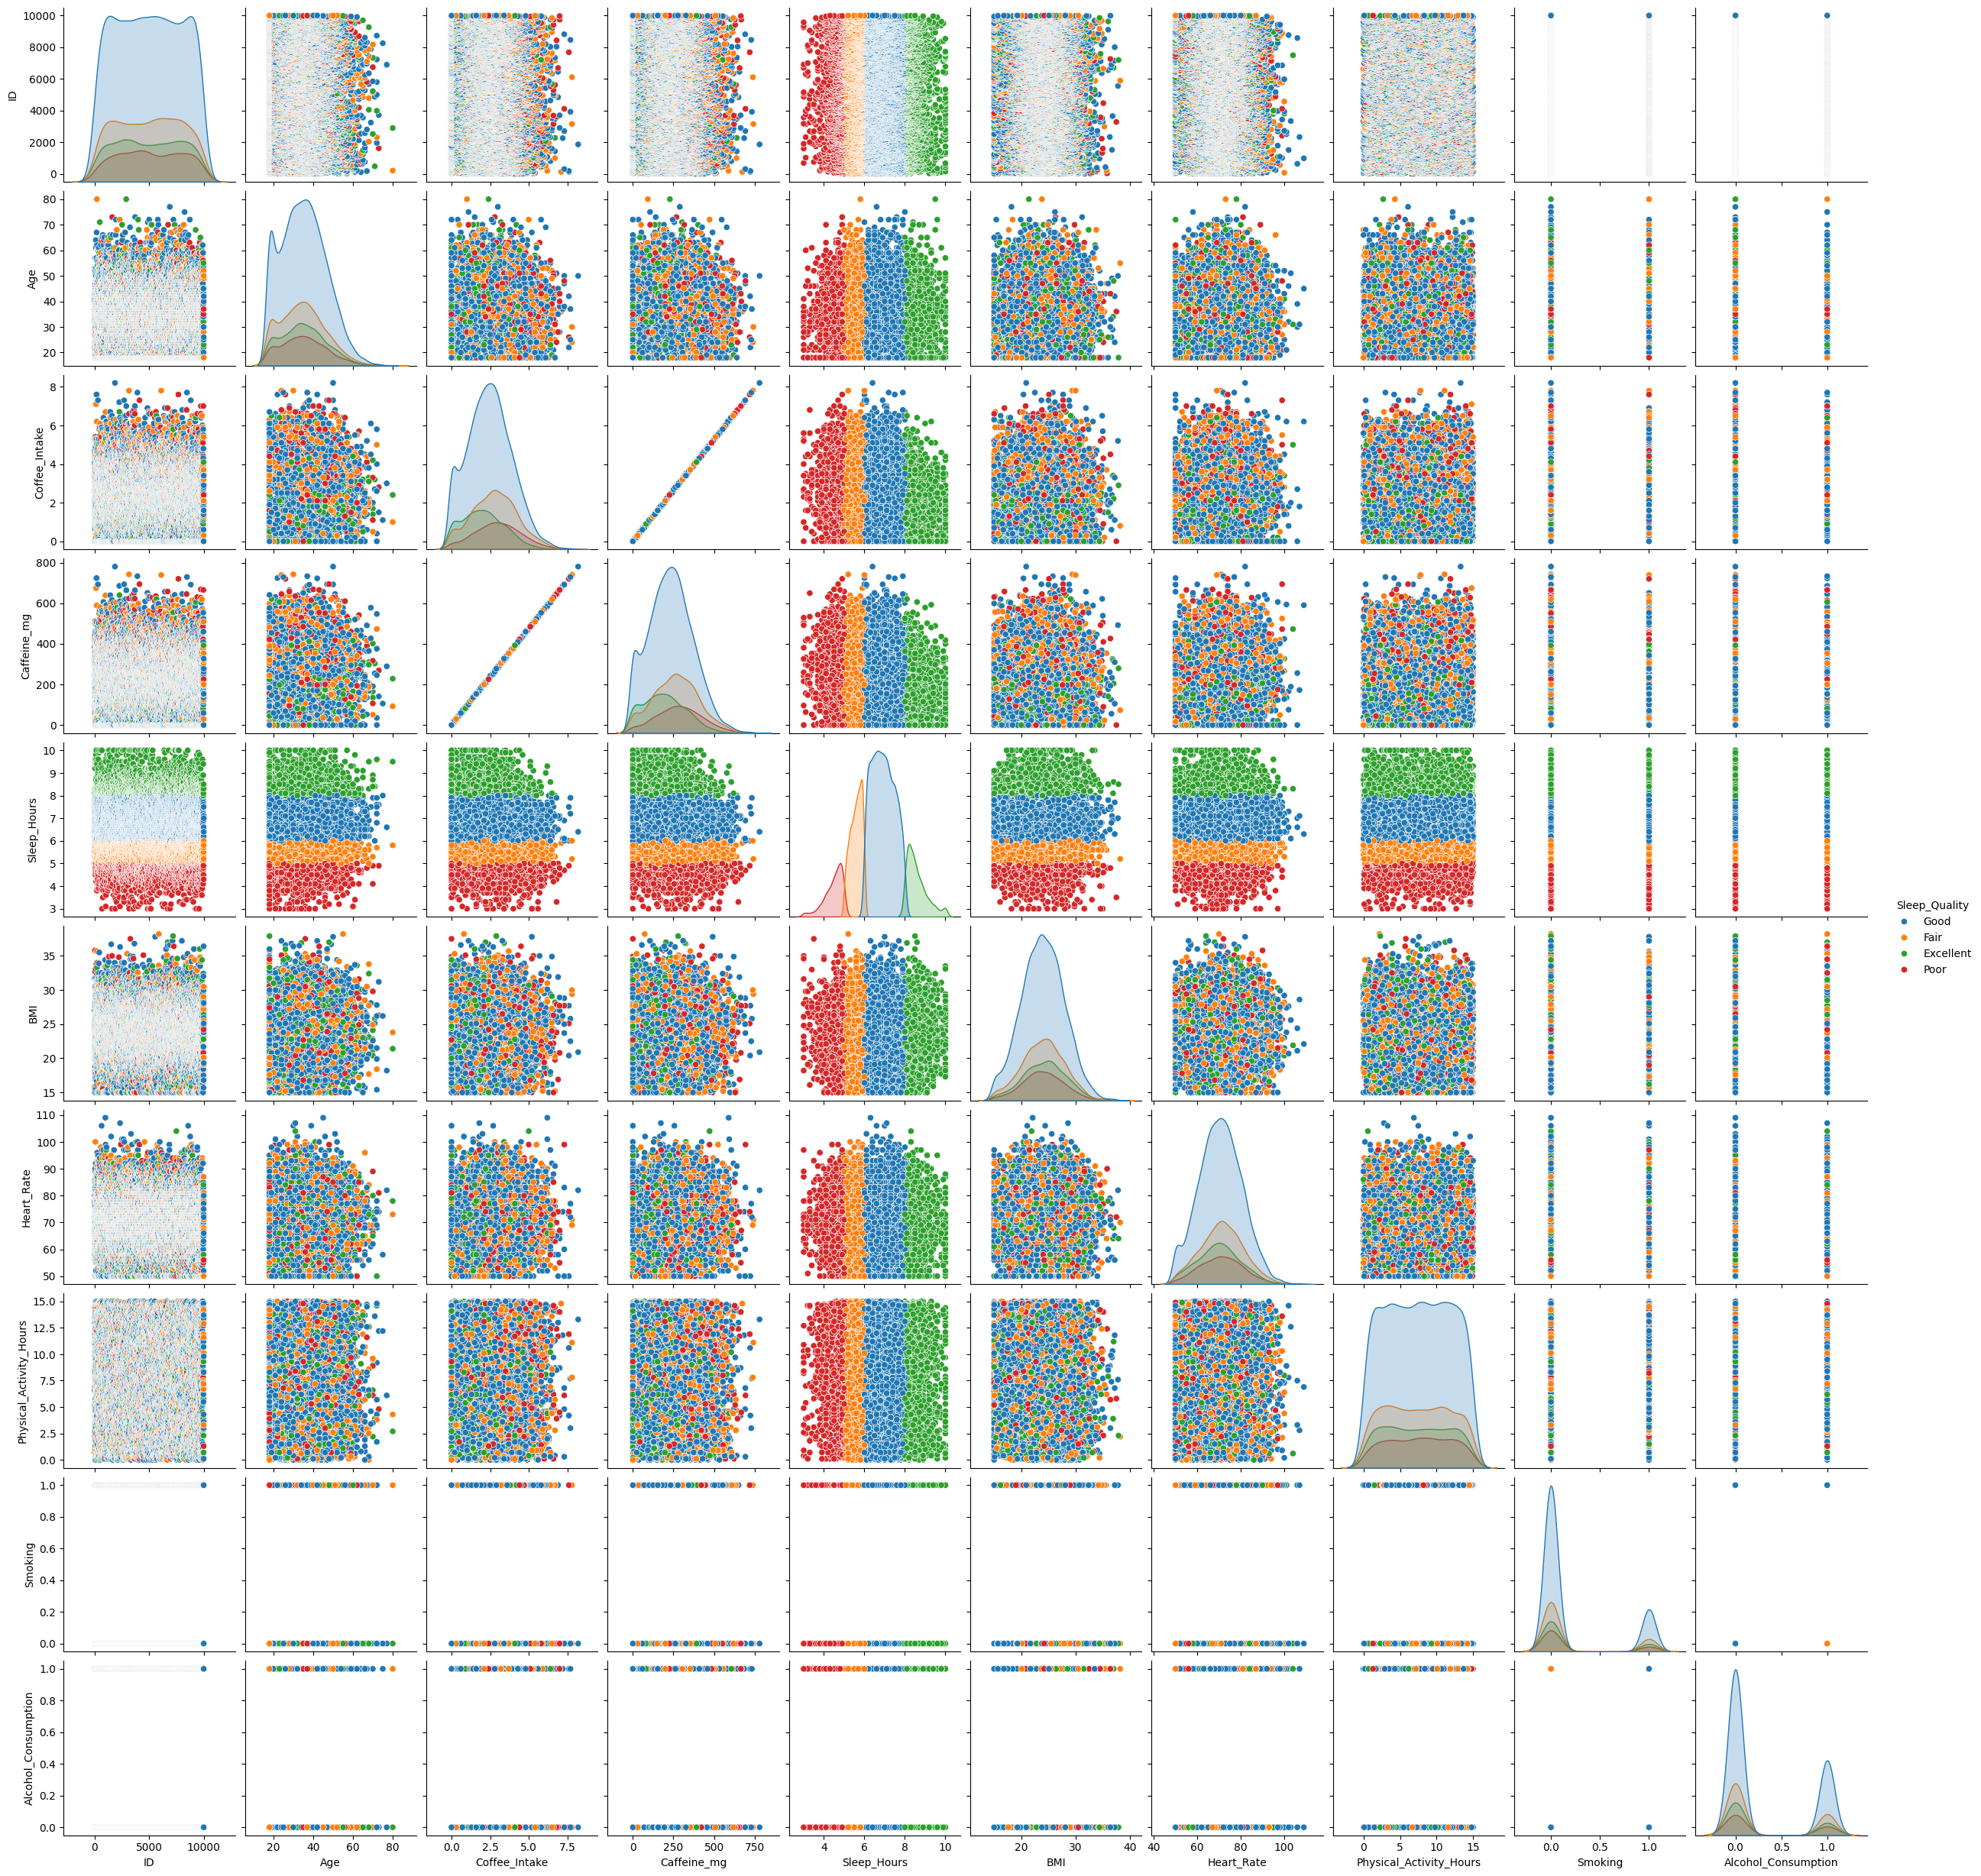

In [15]:
sns.pairplot(data, hue="Sleep_Quality", diag_kind="kde")

It is noticeable that the quantity of sleep hours of an individual affects directly the sleep quality.

    - Poor, 3-5 hours
    - Fair, 5-6 hours
    - Good, 6-8 hours
    - Excellent, 8-10 hours

Effects from another variables may not be as clear as this but it is still somewhat noticeable on the graphs above, we will conduct different statistical analysis tho understand better and in a deep way how our data behaves.

# Unbalanced classes

There are many classes with unbalanced values, such as the Alcohol Consumption, the Smoking Status, the Gender and the Health Issues, we will have to balance this classes in order to improve the predictive cappacity of our models in the future.

# ANOVA

We will proceed with ANOVA to check wich Variables affect the most our target "Sleep_Quality"

But first we will have to balance this class. 

In [ ]:
# ---- Import Libraries for ANOVA ----


# High Importance Classes

We will take an exhaustive look on certain variables that we think have an special importance on the the question we are trying to answer. 

What influenciates the most on the Sleep Quality.




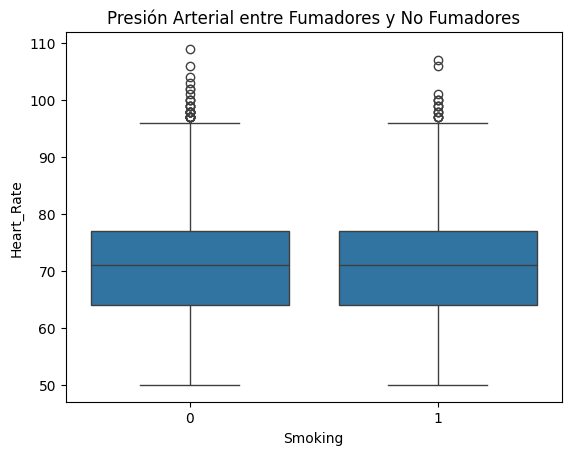

In [64]:
sns.boxplot(x='Smoking', y='Heart_Rate', data=data)
plt.title('Presión Arterial entre Fumadores y No Fumadores')
plt.show()